In [31]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

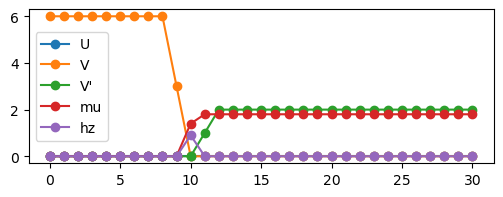

In [32]:
widthD = 10
widthF = 1
widthP = 20

X, Y = widthD+widthF+widthP, 100
lattice = Lattice(X, Y)

t = 1
T = 0.01

muD = 0.0 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthD] = muD
mu[widthD:widthD + widthF] = muF
mu[widthD + widthF:] = muP

h0 = 0.9 * t
h = np.zeros_like(mu)
h[widthD:widthD + widthF] = h0

U0 = 0.0 * t
U = U0 * np.ones(lattice.X)
U[widthD:] = 0
U[widthD-1] = U0/2

V0 = 6.0 * t
V = V0 * np.ones(lattice.X)
V[widthD:] = 0
V[widthD-1] = V0/2

V_prime0 = 2 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD] = 0
V_prime[widthF+widthD] = V_prime0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')

plt.legend()

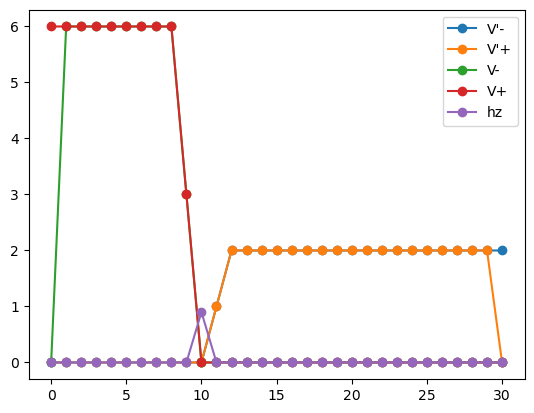

In [33]:
V_plus = np.r_[V[:-1], [0]]
V_minus = np.r_[[0], V[1:]]
Vprime_plus = np.r_[V_prime[:-1], [0]]
Vprime_minus = np.r_[[0], V_prime[1:]]

plt.plot(Vprime_minus, "-o", label="V'-")
plt.plot(Vprime_plus, "-o", label="V'+")
plt.plot(V_minus, "-o", label="V-")
plt.plot(V_plus, "-o", label="V+")
plt.plot(h, '-o', label='hz')
plt.legend()

In [34]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_s=V,
                F_init=[0.3, 0.3, -0.3, -0.3],
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hx=h)

In [35]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=1000, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.024102450850218962
Relative error: 24102450850.218964
Average old: 0j
Average: (-0.0002659087881229884+0j)
F_xplus:
Absolute error: 0.3946076824480498
Relative error: 3350524689.8979754
Average old: (0.1+0j)
Average: (0.05929809893815185+0j)
F_xmin:
Absolute error: 0.3955109074852444
Relative error: 4929155999.686775
Average old: (0.1+0j)
Average: (0.05930014545465665+0j)
F_yplus:
Absolute error: 0.35405580525873387
Relative error: 28394097763.45123
Average old: (-0.0967741935483871+0j)
Average: (-0.06225151987989779+0.00021347022716394537j)
F_ymin:
Absolute error: 0.35405580525873387
Relative error: 28394097763.45123
Average old: (-0.0967741935483871+0j)
Average: (-0.06225151987989779-0.00021347022716394537j)
Fuu_xplus:
Absolute error: 0.13370847734924768
Relative error: 49759345840.377975
Average old: (0.06333333333333334+0j)
Average: (0.04845754181219998+0j)
Fuu_xmin:
Absolute error: 0.13365933769596758
Relative error: 49765872691.04029
Average old: (-0.0633333

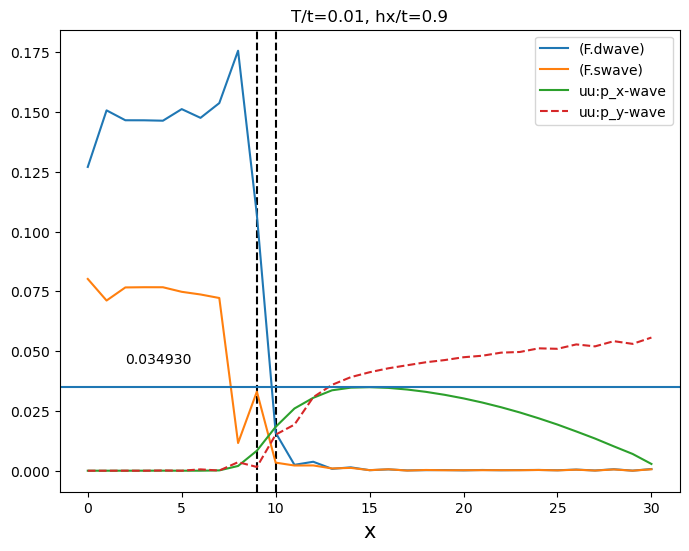

In [36]:
x = np.arange(0, widthD + widthF + widthP)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hx/t={h0}")
axs.axvline(widthD-1, color='black', linestyle='--')
axs.axvline(widthD+widthF-1, color='black', linestyle='--')
axs.plot(x, np.abs(F.dwave), label="(F.dwave)")
axs.plot(x, np.abs(F.swave), label="(F.swave)")
# axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
# axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.set_ylim(None, 0.45)
axs.axhline(np.max(np.abs(Fuu.px)))
axs.text(2, np.max(np.abs(Fuu.px))+0.01, f"{np.max(np.abs(Fuu.px)):.6f}")
axs.legend()
plt.show()

In [37]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.25 + 1e-12, 0.01),
    np.arange(0.26, 0.6 + 1e-12, 0.002 )
])  # 164 temps total
print(len(temps))

205
